In [29]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats=['svg']
%load_ext autoreload
%autoreload 2

# Generic packages
import numpy as np 
from os import listdir


# Machine Learning
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.cluster import KMeans, MiniBatchKMeans


from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm.notebook import tqdm

from numpy import trapz
from scipy.signal import savgol_filter
import torch


from AutoencoderAPI.utils.files import open_object
from AutoencoderAPI.utils.plot import plot_hist
from AutoencoderAPI import autoencoder as auto

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Functions

#### Load traces

In [30]:
class build_dataset:
    def __init__(self, config):
        """
        # __init(config)__

        __init(config)__

            Define parameters to access the dataset

        Parameters
        ----------
            -config (dict) : Parameters (path, signal_size, batch_number) 

        Returns
        -------
            - None
        """
        self.files = listdir(config['path'])
        self.path = config['path']
        self.signal_size = config['signal_size']

        if config['batch_number'] > len(self.files):
            print(f'Batch number too large, was set to {len(self.files)}')
            config['batch_number'] = len(self.files)

        self.batch_split = np.array_split(self.files, config['batch_number'])


    def __getitem__(self,index):
        """
        
        """
        batch = self.batch_split[index]
    
        X = np.concatenate([np.fromfile(f"{self.path}{fileName}",dtype=np.float16).reshape(-1,self.signal_size) for fileName in batch])

        return X

In [31]:
class compare:

    def __init__(self, config):
        
        self.dataset = build_dataset(config)
        self.config = config


    def silhouette_kmean(self, X_list, Title, max_cluster, skip):

        eval_cluster = range(3,max_cluster+1)
        scores = np.zeros((len(X_list) , len(eval_cluster)))

        for index, X in enumerate(X_list):

            if skip > 1:
                X = X[::skip]

            X = (X - np.min(X)) / (np.max(X) - np.min(X)) 
            X = np.array(X).reshape(-1,1)
            
            for cluster_index, cluster_number in tqdm(enumerate(eval_cluster), total=len(eval_cluster) , desc=f"{Title[index]}") :
                
                clusters = MiniBatchKMeans(n_clusters=cluster_number, random_state=42, init="k-means++", n_init='auto', batch_size=4096).fit_predict(X)
                scores[index][cluster_index] = silhouette_score(X, clusters)
    
        plt.figure(figsize=(10,5))
        plt.imshow(scores,aspect='auto')#, interpolation="bilinear")
        plt.xticks(np.arange(len(eval_cluster)), labels=eval_cluster)
        plt.yticks(np.arange(len(Title)), labels=Title)
        plt.colorbar()

        for (j,i),label in np.ndenumerate(scores):
            plt.text(i,j,round(label,2),ha='center',va='center')
            plt.text(i,j,round(label,2),ha='center',va='center')

        plt.show()

            

        return eval_cluster, scores



    def max_value(self):

        X_filter = savgol_filter(self.dataset.__getitem__(0), 20, 2)
        feature = np.max(X_filter, axis=1)
        
        if self.config['batch_number'] > 1:
            for batch_index in range(1, self.config['batch_number']):

                X_filter = savgol_filter(self.dataset.__getitem__(batch_index), 20, 2)
                feature = np.append(feature, np.max(X_filter, axis=1))

        return feature

    

    def area(self):

        X_filter = savgol_filter(self.dataset.__getitem__(0), 20, 2)
        feature = trapz(X_filter, dx=1)
        
        if self.config['batch_number'] > 1:
            for batch_index in range(1, self.config['batch_number']):

                X_filter = savgol_filter(self.dataset.__getitem__(batch_index), 20, 2) 
                feature = np.append(feature, trapz(X_filter, dx=1))

        return feature


    def principal_component(self):

        pca = IncrementalPCA(n_components=1, batch_size=100)
        feature = pca.fit_transform(self.dataset.__getitem__(0))

        return feature

    
    def autoencoder(self, model):

        path = f"Autoencoder Log/{model}"
        config_load = open_object(f"{path}/log.bin")

        network = auto.build_autoencoder(config_load)
        network.load_state_dict(torch.load(f"{path}/model.pt"))
        network.eval()

        X_pytorch = torch.from_numpy(self.dataset.__getitem__(0)).view(-1, 1, config_load['files']['input_dimension']).float()
        feature = network(X_pytorch, encoding=True).detach().numpy().reshape(-1)

        return feature

In [32]:
config = {
    'path'         : "Datasets/NIST PIKA 1 (4096)/",#Oxford/", #NIST (250)/", #Oxford/",#
    'signal_size'  : 4096,#496,#496,#250,#800,
    'batch_number' : 1
}

### Experiments

In [33]:
comp = compare(config)

In [34]:
feature_MV = comp.max_value()

In [35]:
feature_AR = comp.area()

In [36]:
feature_PCA = comp.principal_component()

In [37]:
feature_AUTO = comp.autoencoder(model='run-2023-08-18-20-38/fold 0')

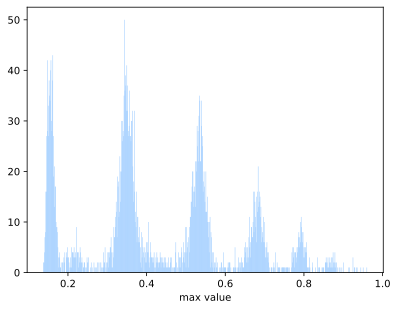

In [38]:
plot_hist(feature_MV, "max value")

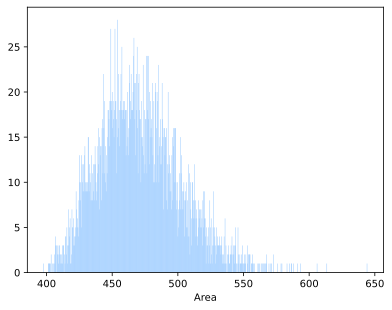

In [39]:
plot_hist(feature_AR, "Area")

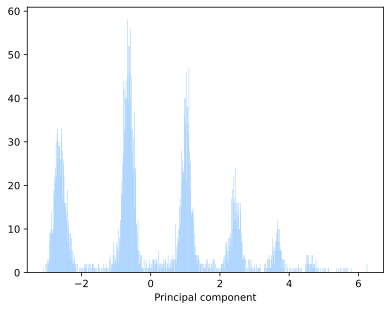

In [40]:
plot_hist(feature_PCA, "Principal component")

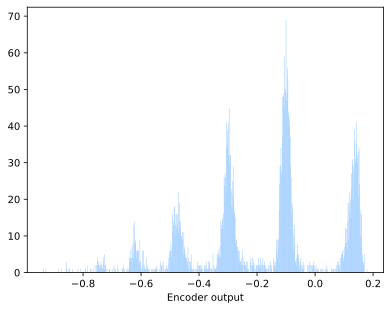

In [41]:
plot_hist(feature_AUTO, "Encoder output")

Max Value:   0%|          | 0/8 [00:00<?, ?it/s]

Area:   0%|          | 0/8 [00:00<?, ?it/s]

PCA:   0%|          | 0/8 [00:00<?, ?it/s]

Autoencoder:   0%|          | 0/8 [00:00<?, ?it/s]

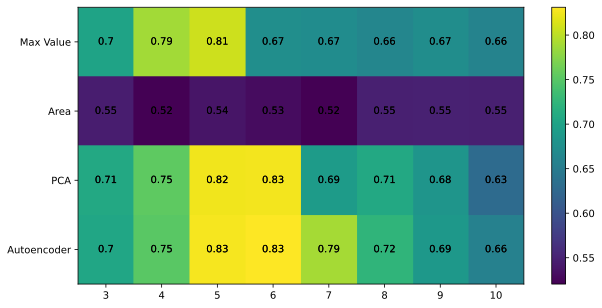

(range(3, 11),
 array([[0.70065719, 0.78794251, 0.80769427, 0.6737404 , 0.67199649,
         0.6624865 , 0.6731473 , 0.6592359 ],
        [0.54540721, 0.52041969, 0.53796815, 0.5308416 , 0.5213722 ,
         0.54767323, 0.54917546, 0.54798449],
        [0.70757719, 0.75455396, 0.82449348, 0.82536456, 0.69111052,
         0.70770196, 0.6825467 , 0.62930317],
        [0.70420647, 0.75120997, 0.82721341, 0.83126265, 0.78963822,
         0.72376955, 0.68564868, 0.65662485]]))

In [42]:
X_list = [feature_MV, feature_AR, feature_PCA, feature_AUTO]
Title = ["Max Value", "Area", "PCA", "Autoencoder"]

comp.silhouette_kmean(X_list, Title, max_cluster=10, skip=10)